## Task 3: Analyze model performance using confusion matrix, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

### Subtask 3.1: Plotting the Confusion Matrix Heatmap
**Concept:** Generate a confusion matrix to visualize true positives, false positives, true negatives, and false negatives in your classification results.


In [5]:
#code from task 1&2
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
from sklearn.metrics import confusion_matrix

In [9]:
cm = confusion_matrix(y_test, lr_preds)

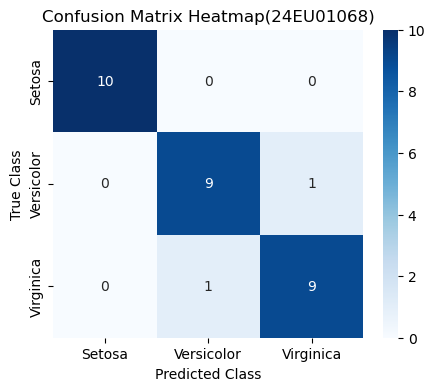

In [10]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap(24EU01068)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

### Subtask 3.2: Precision, Recall, F1-Score, and Support Analysis
**Concept:** Generate a detailed classification report to compute and analyze continuous performance metrics for both target classes.


In [11]:
from sklearn.metrics import classification_report

In [12]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

In [13]:
print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [14]:
from sklearn.preprocessing import label_binarize

In [15]:
from sklearn.metrics import roc_curve, auc

In [16]:
import matplotlib.pyplot as plt

In [17]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [18]:
y_score = lr_model.predict_proba(X_test)

In [19]:
plt.figure(figsize=(7,6))

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

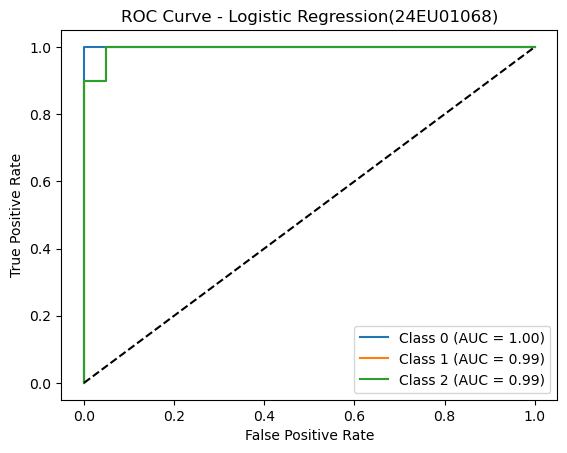

In [22]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression(24EU01068)")
plt.legend(loc="lower right")
plt.show()

## Cross Validation

In [23]:
from sklearn.datasets import load_iris

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
from sklearn.model_selection import cross_val_score

In [27]:
import numpy as np

In [28]:
iris = load_iris()

In [29]:
X = iris.data

In [30]:
y = iris.target

In [31]:
scaler = StandardScaler()

In [32]:
X_scaled = scaler.fit_transform(X)

In [33]:
lr_model = LogisticRegression(max_iter=200)

In [34]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

In [35]:
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%
